In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.ops import nms
from torchvision.ops import batched_nms


In [2]:
import yaml
import numpy as np
import cv2
import os
from PIL import Image

In [3]:
class ConvBlock(nn.Module):
    def __init__(self, inChannels, outChannels, kernelSize=3, stride=1, padding=1):
        """Conv -> BatchNorm -> ReLU"""
    
        super(ConvBlock, self).__init__()
        self.convolution = nn.Conv2d(inChannels, outChannels, kernelSize, stride, padding)
        self.batchNorm = nn.BatchNorm2d(outChannels)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.batchNorm(self.convolution(x)))

In [4]:
class ModelBackbone(nn.Module):
    def __init__(self):
        """Add together conv"""
        super(ModelBackbone, self).__init__()
        self.layers = nn.Sequential(
            ConvBlock(3, 32, kernelSize=3, stride=1, padding=1),
            nn.MaxPool2d(2, 2),
            ConvBlock(32, 64, kernelSize=3, stride=1, padding=1),
            nn.MaxPool2d(2, 2),
            ConvBlock(64, 128, kernelSize=3, stride=1, padding=1),
            nn.MaxPool2d(2, 2),
        )

    def forward(self, x):
        return self.layers(x)

In [5]:
class ModelHead(nn.Module):
    def __init__(self, gridSize, numClasses, numAnchors):
        """Predicts bbox, conf, cls"""
        super(ModelHead, self).__init__()
        self.gridSize = gridSize
        self.numClasses = numClasses
        self.numAnchors = numAnchors

        self.detector = nn.Conv2d(128, self.numAnchors * (5 + self.numClasses), kernel_size=1)
        
    def forward(self, x):
        pred = self.detector(x)
        pred = pred.permute(0, 2, 3, 1).contiguous()

        batchSize, h, w, _ = pred.shape

        pred = pred.view(batchSize, h, w, self.numAnchors, 5 + self.numClasses)

        return pred

In [6]:
class TLDetectionModel(nn.Module):
    def __init__(self, gridSize=7, numClasses=20, numAnchors=3):
        super(TLDetectionModel, self).__init__()
        self.backbone = ModelBackbone()
        self.head = ModelHead(gridSize, numClasses, numAnchors)

    def forward(self, x):
        features = self.backbone(x)
        predictions = self.head(features)
        return predictions


In [7]:
model = TLDetectionModel(gridSize=64, numClasses=3, numAnchors=3)
model.load_state_dict(torch.load("model.pth"))
model.to('cuda')
model.eval()

TLDetectionModel(
  (backbone): ModelBackbone(
    (layers): Sequential(
      (0): ConvBlock(
        (convolution): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (batchNorm): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu): ReLU()
      )
      (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (2): ConvBlock(
        (convolution): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (batchNorm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu): ReLU()
      )
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): ConvBlock(
        (convolution): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (batchNorm): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu): ReLU()


In [8]:
class InferenceRunner:
    def __init__(self, device="cuda"):
        self.transform = transforms.Compose([transforms.Resize((512, 512)), transforms.ToTensor(),])   
        self.device = "cuda"
        
        self.anchors = torch.tensor([
            [10, 13],
            [16, 30],
            [33, 23]
        ], device=self.device).float()

    def run(self, cv2Img, thresh=0.85):
        
        image = Image.fromarray(cv2.cvtColor(cv2Img, cv2.COLOR_BGR2RGB))
        inputTensor = self.transform(image).unsqueeze(0).to('cuda') 

        with torch.no_grad():
            output = model(inputTensor)
            
        print("Output Shape", output.shape)

        batch, gridH, gridW, numAnchors, predSize = output.shape

        pred = output[0]         
        pred[..., 0:2] = torch.sigmoid(pred[..., 0:2])  # x, y
        pred[..., 4:]  = torch.sigmoid(pred[..., 4:])  # conf + classes

        gridX, gridY = self.getGridXY(gridW, gridH)
                
        bx, by, bw, bh = self.getborders(numAnchors, pred, gridX, gridY, gridW, gridH)

        classPred, finalConf = self.getPredConf(pred)

        bx = bx.reshape(-1)
        by = by.reshape(-1)
        bw = bw.reshape(-1)
        bh = bh.reshape(-1)
        finalConf = finalConf.reshape(-1)
        classPred = classPred.reshape(-1)

        mask = finalConf > 0.85

        bx = bx[mask]
        by = by[mask]
        bw = bw[mask]
        bh = bh[mask]
        scores = finalConf[mask]
        labels = classPred[mask]
        
        boxes_nms, scores_nms, labels_nms = self.getBatchedNMS(scores, labels, bx, by, bw, bh)
        boxes_nms, scores_nms, labels_nms = self.mergeBoxesByLabel(boxes_nms, scores_nms, labels_nms)
        
        print("Boxes:", boxes_nms)
        print("Scores:", scores_nms)
        print("Labels:", labels_nms)

        boxesNP = boxes_nms.detach().cpu().numpy()
        boxesPX = self.getBoxesPx(boxesNP, cv2Img)
        scoresNP = scores_nms.detach().cpu().numpy()
        labelsNP = labels_nms.detach().cpu().numpy()

        return boxesNP, boxesPX, scoresNP, labelsNP

    def getBatchedNMS(self, scores, labels, bx, by, bw, bh):
        x1 = bx - bw / 2
        y1 = by - bh / 2
        x2 = bx + bw / 2
        y2 = by + bh / 2
        
        boxes = torch.stack([x1, y1, x2, y2], dim=1)        
        keep = batched_nms(boxes, scores, labels, iou_threshold=0.5)
        
        return boxes[keep], scores[keep], labels[keep]

    def getBoxesPx(self, boxes, image):       
        h, w, _ = image.shape
        boxesPx = boxes.copy()
        boxesPx[:, 0] *= w  # x1
        boxesPx[:, 1] *= h  # y1
        boxesPx[:, 2] *= w  # x2
        boxesPx[:, 3] *= h  # y2
        
        return boxesPx.astype(int)

    def getPredConf(self, pred):
        conf = pred[..., 4]
        classProbs = pred[..., 5:]
        
        classConf, classPred = torch.max(classProbs, dim=-1)
        finalConf = conf * classConf

        return classPred, finalConf
    
    def getGridXY(self, gridW, gridH):
        gridX = torch.arange(gridW, device=self.device).repeat(gridH, 1)
        gridY = gridX.t()
        
        gridX = gridX.view(1, gridH, gridW, 1)
        gridY = gridY.view(1, gridH, gridW, 1)

        return gridX, gridY
    
    def getborders(self, numAnchors, pred, gridX, gridY, gridW, gridH):
        anchors = self.anchors.view(1, 1, 1, numAnchors, 2)

        bx = (pred[..., 0] + gridX) / gridW
        by = (pred[..., 1] + gridY) / gridH
        
        bw = anchors[..., 0] * torch.exp(pred[..., 2]) / 512
        bh = anchors[..., 1] * torch.exp(pred[..., 3]) / 512

        return bx, by, bw, bh

    def mergeBoxesByLabel(self, boxes, scores, labels):
        mergedBoxes = []
        mergedScores = []
        mergedLabels = []
    
        uniqueLabels = labels.unique()
    
        for cls in uniqueLabels:
            mask = labels == cls
    
            clsBoxes = boxes[mask]
            clsScores = scores[mask]
    
            if len(clsBoxes) == 0:
                continue
    
            x1 = clsBoxes[:, 0].min()
            y1 = clsBoxes[:, 1].min()
            x2 = clsBoxes[:, 2].max()
            y2 = clsBoxes[:, 3].max()
    
            mergedBox = torch.tensor([x1, y1, x2, y2], device=boxes.device)
    
            mergedScore = clsScores.max()
    
            mergedBoxes.append(mergedBox)
            mergedScores.append(mergedScore)
            mergedLabels.append(cls)
    
        return (torch.stack(mergedBoxes), torch.stack(mergedScores), torch.stack(mergedLabels))

        

In [9]:
cv2Img = cv2.imread(r"C:\PROJECTS\TrafficLightDetectionTutorial\TrainData\test\images\0168.png")

inferenceRunner = InferenceRunner()

boxesNP, boxesPX, scoresNP, labelsNP = inferenceRunner.run(cv2Img, thresh=0.6)

print(f"---Final boxes {boxesNP} \n---boxes(Pixels) {boxesPX} \n---scores {scoresNP} \n---labels {labelsNP}")

Output Shape torch.Size([1, 64, 64, 3, 8])
Boxes: tensor([[0.3764, 0.4809, 0.4407, 0.5531],
        [0.4694, 0.4813, 0.5180, 0.5391]], device='cuda:0')
Scores: tensor([0.9998, 0.9995], device='cuda:0')
Labels: tensor([0, 1], device='cuda:0')
---Final boxes [[0.37641042 0.4808704  0.44065744 0.5530871 ]
 [0.4694241  0.48129573 0.51801294 0.53911436]] 
---boxes(Pixels) [[210 269 246 309]
 [262 269 290 301]] 
---scores [0.99978495 0.9995137 ] 
---labels [0 1]


In [10]:
img = cv2Img.copy()

for i in range(len(boxesPX)):
    x1, y1, x2, y2 = boxesPX[i]
    score = scoresNP[i]
    label = labelsNP[i]

    print(label)
    
    color = (0, 0, 105)
    if (label == 2):
        color = (0, 105, 0)
    elif (label == 1):
        color = (0, 105, 105)        

    centerPoint = ((x1 + x2) // 2, (y1 + y2) // 2)
    
    cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
    cv2.circle(img, centerPoint, radius=2, color=(0, 0, 0), thickness=-1)

    text = f"{label}"
    text2 = f"{score:.3f}"
        
    cv2.putText(img, text, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, tuple(c * 2 for c in color), 1)
    cv2.putText(img, text2, (x1 - 10, y2 + 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, tuple(c * 2 for c in color), 1)

0
1


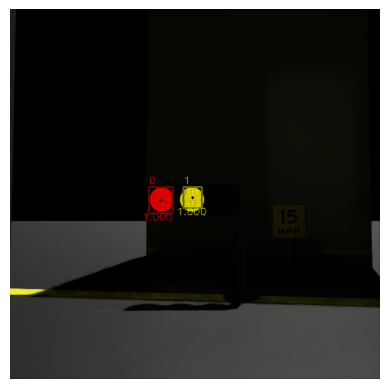

In [11]:
from matplotlib import pyplot as plt

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [12]:
cv2.imwrite("output.png", img)

True